# Environment test

## 1. Verify data science/ML libraries

Check that TensorFlow and PyTorch are importable and are the correct versions

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import torch

print('TensorFlow version:', tf.__version__)
print('PyTorch version:', torch.__version__)


TensorFlow version: 2.16.1
PyTorch version: 2.5.1


Check that GPU(s) are correctly detected and available for both frameworks. The `gpu_available` flag set here is used by the GPU load test sections below, those sections are skipped automatically on CPU-only machines.

In [2]:
#  TensorFlow GPU detection
tf_gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow GPUs:')

if tf_gpus:
    for i, gpu in enumerate(tf_gpus):

        details = tf.config.experimental.get_device_details(gpu)
        cc = details.get('compute_capability', (0, 0))
        device = details.get('device_name', '')
    
        print(f'  GPU {i}: {device}, compute capability {cc[0]}.{cc[1]}')

# PyTorch GPU detection
print(f'\nPyTorch GPUs:')

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}, compute capability {torch.cuda.get_device_capability(i)[0]}.{torch.cuda.get_device_capability(i)[1]}')

# Flag used by GPU load test sections below
gpu_available = torch.cuda.is_available() or len(tf_gpus) > 0

TensorFlow GPUs:
  GPU 0: NVIDIA GeForce GTX 1070, compute capability 6.1

PyTorch GPUs:
  GPU 0: NVIDIA GeForce GTX 1070, compute capability 6.1


Check other data science libraries:

In [3]:
import matplotlib as mpl
import numpy as np
import pandas as pd
import scipy as sp
import sklearn as sk

print('Matplotlib version:', mpl.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)
print('Scikit-learn version:', sk.__version__)
print('SciPy version:', sp.__version__)

Matplotlib version: 3.10.9
NumPy version: 1.24.4
Pandas version: 2.2.2
Scikit-learn version: 1.4.2
SciPy version: 1.14.0


## 2. GPU load test

Runs a TensorFlow matrix multiplication stress test. Skipped automatically if no GPU was detected above.

In [4]:
# GPU load test - Matrix multiplication with memory scaling
if not gpu_available:
    print('No GPU detected - skipping GPU load test.')

else:
    from functions.gpu_load_test import run_gpu_load_test

    target_memory_percent = 75.0
    test_duration_seconds = 10 * 60

    gpu_results = run_gpu_load_test(target_memory_percent, test_duration_seconds)

Memory growth enabled for 1 GPU(s)
Testing GPU 0: /physical_device:GPU:0
Total GPU memory: 8192 MB
Initial memory used: 1493 MB (18.2%)
Target: 75.0% memory usage

Trying matrix size: 1000x1000... Memory: 1573 MB (19.2%)
Trying matrix size: 2000x2000... Memory: 1669 MB (20.4%)
Trying matrix size: 3000x3000... Memory: 2051 MB (25.0%)
Trying matrix size: 4000x4000... Memory: 2051 MB (25.0%)
Trying matrix size: 5000x5000... Memory: 2563 MB (31.3%)
Trying matrix size: 6000x6000... Memory: 3586 MB (43.8%)
Trying matrix size: 7000x7000... Memory: 3582 MB (43.7%)
Trying matrix size: 8000x8000... Memory: 3582 MB (43.7%)
Trying matrix size: 9000x9000... Memory: 5634 MB (68.8%)
Trying matrix size: 10000x10000... Memory: 5622 MB (68.6%)
Trying matrix size: 11000x11000... Memory: 5627 MB (68.7%)
Trying matrix size: 12000x12000... Memory: 7345 MB (89.7%)

Reached 89.7% memory usage with 12000x12000 matrices

Running stress test for 10 minutes at 12000x12000...
Initial temperature: 63°C
  31s elapse

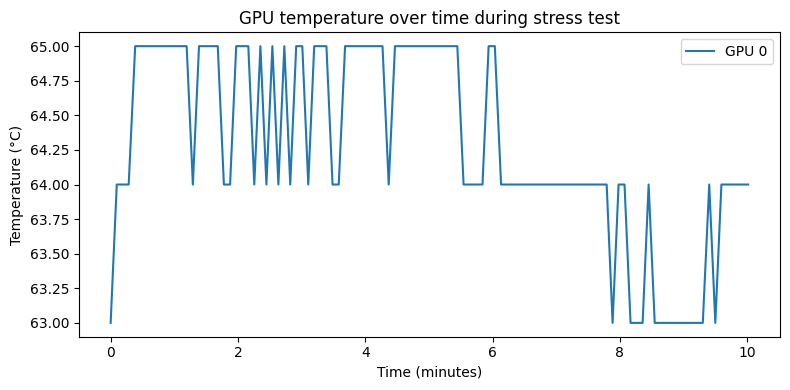

In [5]:
# Plot temperature over time for each GPU
if not gpu_available:
    print('No GPU detected - skipping plot.')

else:
    from functions.gpu_load_test import plot_temperature_results

    plot_temperature_results(gpu_results)

## 3. PyTorch GPU load test

Runs a PyTorch matrix multiplication stress test. Skipped automatically if no GPU was detected above.

In [6]:
# PyTorch GPU load test - Matrix multiplication with memory scaling
if not gpu_available:
    print('No GPU detected - skipping PyTorch GPU load test.')

else:
    from functions.pytorch_gpu_load_test import run_pytorch_gpu_load_test

    target_memory_percent = 75.0
    test_duration_seconds = 10 * 60

    pytorch_gpu_results = run_pytorch_gpu_load_test(target_memory_percent, test_duration_seconds)

Found 1 CUDA GPU(s)
  GPU 0: NVIDIA GeForce GTX 1070
Testing GPU 0: NVIDIA GeForce GTX 1070
Total GPU memory: 8192 MB
Initial memory used: 7486 MB (91.4%)
Target: 75.0% memory usage

Trying matrix size: 1000x1000... Memory: 7513 MB (91.7%)

Reached 91.7% memory usage with 1000x1000 matrices

Running stress test for 10 minutes at 1000x1000...
Initial temperature: 63°C
  30s elapsed, 570s remaining - Temp: 76°C, Iterations: 47415
  60s elapsed, 540s remaining - Temp: 76°C, Iterations: 94611
  90s elapsed, 510s remaining - Temp: 77°C, Iterations: 141987
  120s elapsed, 480s remaining - Temp: 76°C, Iterations: 188159
  150s elapsed, 450s remaining - Temp: 77°C, Iterations: 235901
  180s elapsed, 420s remaining - Temp: 76°C, Iterations: 283793
  210s elapsed, 390s remaining - Temp: 76°C, Iterations: 329030
  240s elapsed, 360s remaining - Temp: 76°C, Iterations: 376645
  270s elapsed, 330s remaining - Temp: 75°C, Iterations: 424546
  300s elapsed, 300s remaining - Temp: 76°C, Iterations: 47

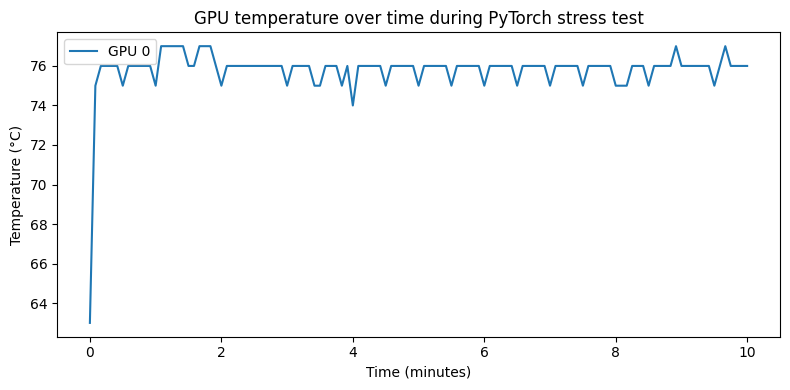

In [7]:
# Plot temperature over time for each GPU
if not gpu_available:
    print('No GPU detected - skipping plot.')

else:
    from functions.pytorch_gpu_load_test import plot_temperature_results

    plot_temperature_results(pytorch_gpu_results)